In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Rectangle
import os

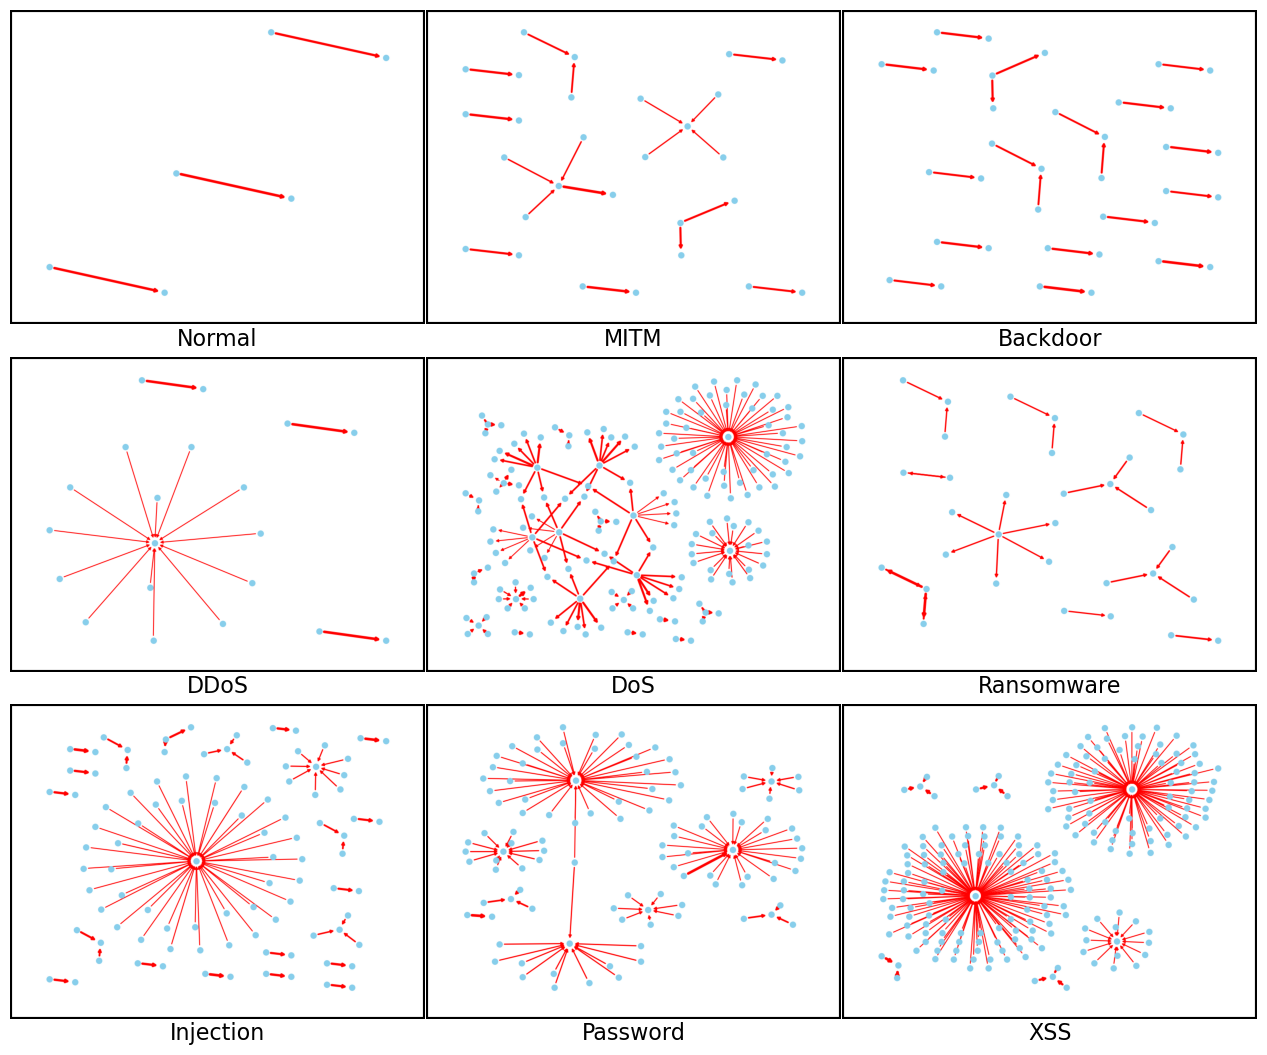

In [8]:
image_folder = "../tmp/fig"
image_files = [
    os.path.join(image_folder, 'explanation_Normal.png'),
    os.path.join(image_folder, 'explanation_MITM.png'),
    os.path.join(image_folder, 'explanation_Backdoor.png'),

    os.path.join(image_folder, 'explanation_DDoS.png'),
    os.path.join(image_folder, 'explanation_DoS.png'),
    os.path.join(image_folder, 'explanation_Ransomware.png'),

    os.path.join(image_folder, 'explanation_Injection.png'),
    os.path.join(image_folder, 'explanation_Password.png'),
    os.path.join(image_folder, 'explanation_XSS.png'),
]

# Rács mérete
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(12.5, 10.5))

for i, ax in enumerate(axes.flat):
    if i < len(image_files):
        img = mpimg.imread(image_files[i])
        img_cropped = img[40:, :, :]  # crop top 40px

        img_artist = ax.imshow(img_cropped)
        ax.axis("off")

        # draw borders
        extent = img_artist.get_extent()  # (x0, x1, y0, y1)
        rect = Rectangle(
            (extent[0], extent[2]),
            extent[1] - extent[0],
            extent[3] - extent[2],
            linewidth=3,
            edgecolor='black',
            facecolor='none'
        )
        ax.add_patch(rect)

        filename = os.path.basename(image_files[i])
        attack_type = filename.replace("explanation_", "").replace(".png", "")

        ax.text(
            0.5, -0.01, attack_type,
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=16
        )
    else:
        ax.axis("off")

plt.tight_layout(pad=0.1, h_pad=0.4, w_pad=0.1)
plt.show()